##Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib

RANDOM_STATE = 42

In [2]:
data = pd.read_csv('/content/dataset_A_training.csv')

print('Dataset loaded successfully')
print('Shape:', data.shape)
data.head()

Dataset loaded successfully
Shape: (4756, 31)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [3]:
target = 'seasonal_vaccine'
id_col = 'respondent_id'

print('Target column:', target)
print('ID column:', id_col)

Target column: seasonal_vaccine
ID column: respondent_id


#Data Exploration

##Basic dataset information




In [5]:
print('Rows and columns:', data.shape)
print('Column names:')
print(data.columns.tolist())

print('Data types:')
print(data.dtypes)

print('Duplicate rows:', data.duplicated().sum())

Rows and columns: (4756, 31)
Column names:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'household_adults', 'household_children', 'employment_sector', 'seasonal_vaccine']
Data types:
respondent_id                    int64
flu_concern                    float64
flu_knowledge                  float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    flo

In [6]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,NaN,NaN,NaN,1.643128,0.91981,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,NaN,NaN,NaN,1.293049,0.618902,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.052299,0.222652,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,NaN,NaN,NaN,0.734124,0.441846,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,NaN,NaN,NaN,0.073848,0.261551,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.836563,0.369803,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.365494,0.481619,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,NaN,NaN,NaN,0.336634,0.472608,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,NaN,NaN,NaN,0.68841,0.463192,0.0,0.0,1.0,1.0,1.0


##Target distribution

seasonal_vaccine
1    2551
0    2205
Name: count, dtype: int64
Percentage:
seasonal_vaccine
1    53.64
0    46.36
Name: proportion, dtype: float64


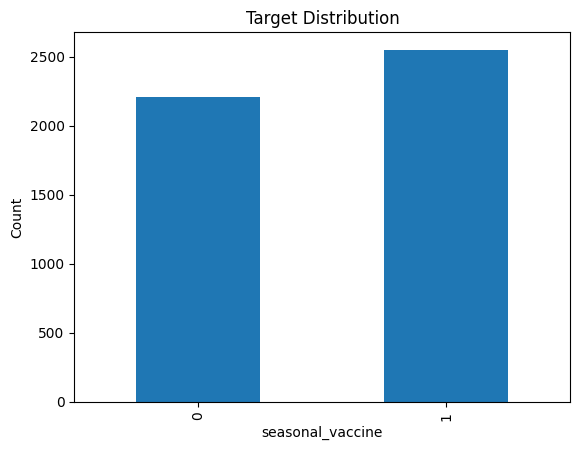

In [7]:
print(data[target].value_counts())
print('Percentage:')
print((data[target].value_counts(normalize=True) * 100).round(2))

data[target].value_counts().sort_index().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel(target)
plt.ylabel('Count')
plt.show()

##Missing values

employment_sector              2314
health_insurance               1925
income_poverty                  790
rent_or_own                     381
doctor_recc_seasonal            321
education                       270
employment_status               269
marital_status                  265
chronic_med_condition           188
child_under_6_months            152
health_worker                   149
opinion_seas_risk               102
opinion_seas_sick_from_vacc     101
opinion_seas_vacc_effective      94
household_adults                 44
household_children               44
behavioral_avoidance             32
flu_knowledge                    23
behavioral_touch_face            19
behavioral_antiviral_meds        14
flu_concern                      12
behavioral_large_gatherings       9
behavioral_outside_home           9
behavioral_wash_hands             8
behavioral_face_mask              3
dtype: int64


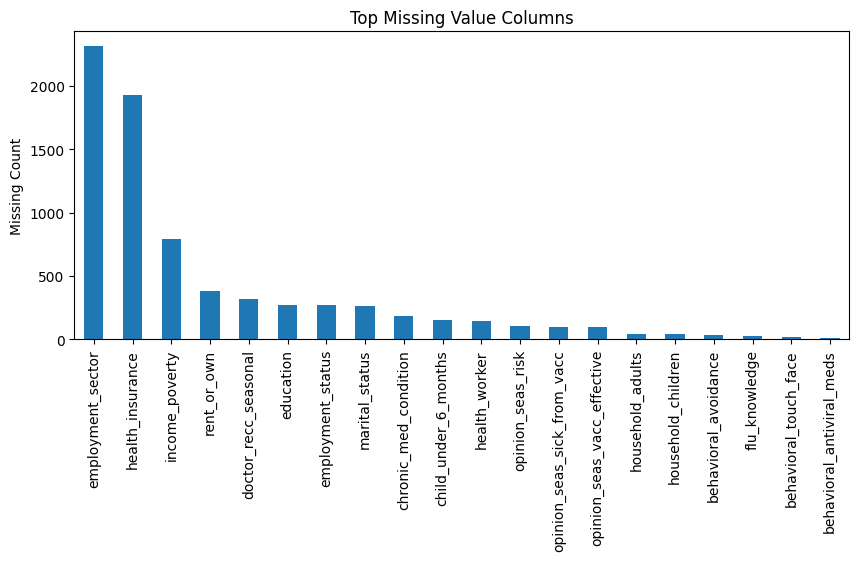

In [8]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

if len(missing) > 0:
    missing.head(20).plot(kind='bar', figsize=(10, 4))
    plt.title('Top Missing Value Columns')
    plt.ylabel('Missing Count')
    plt.show()
else:
    print('No missing values found')

##Numerical columns

In [12]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

if target in numeric_cols:
    numeric_cols.remove(target)
if id_col in numeric_cols:
    numeric_cols.remove(id_col)

print('Number of numerical columns:', len(numeric_cols))
print(numeric_cols)

Number of numerical columns: 19
['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']


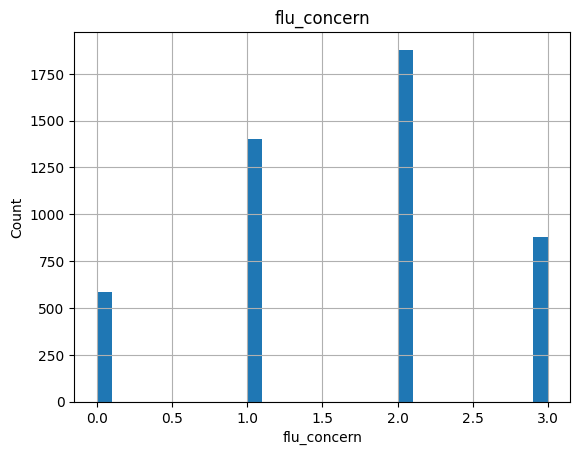

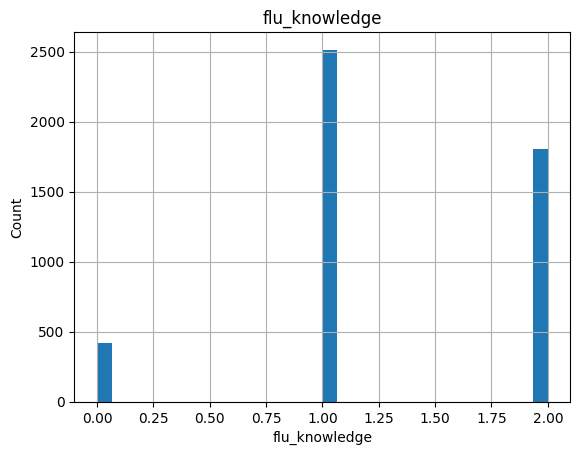

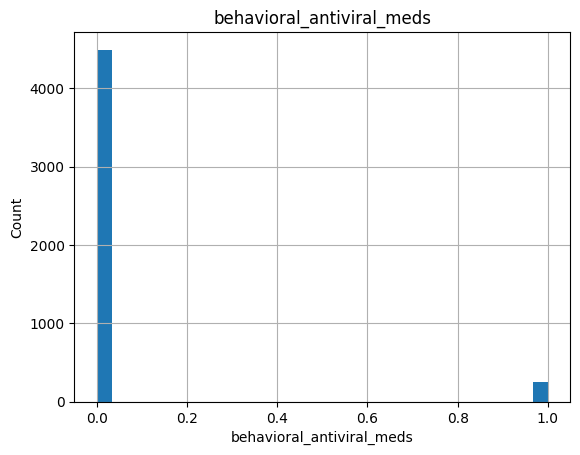

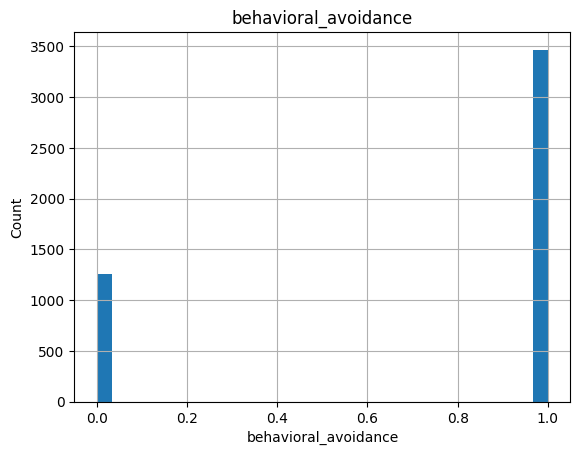

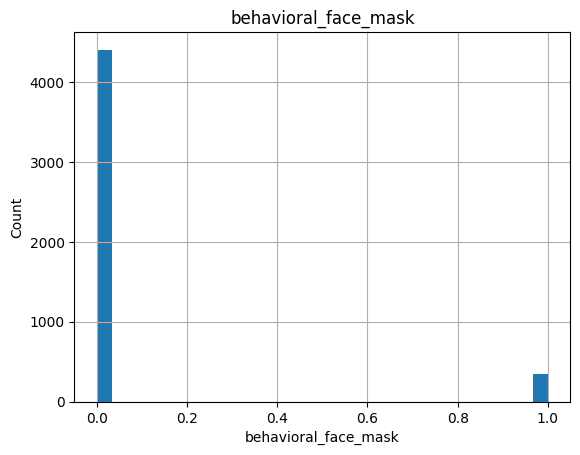

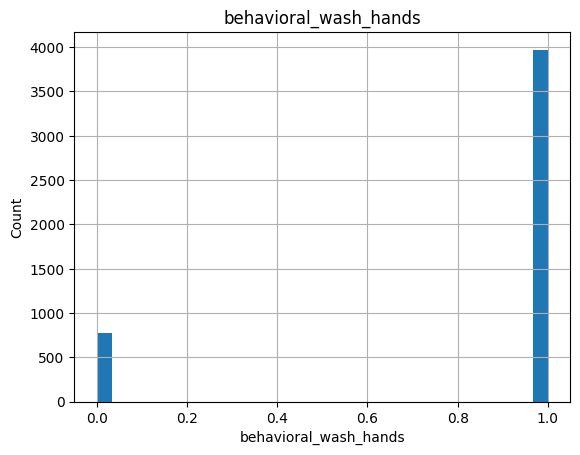

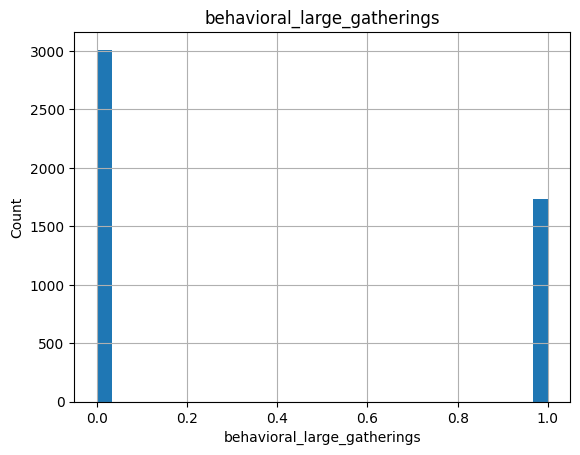

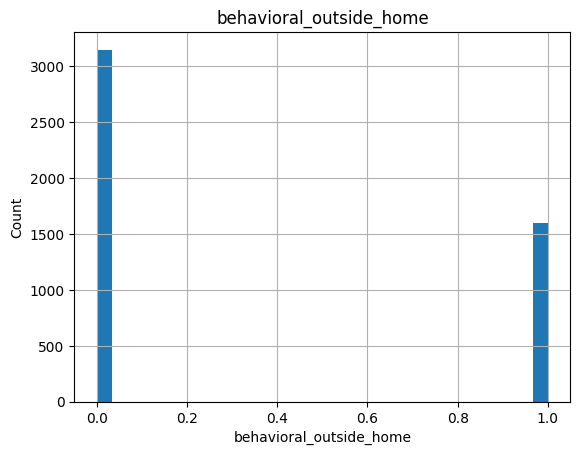

In [13]:
for col in numeric_cols[:8]:
    data[col].hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

##Categorical columns

In [14]:
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

print('Number of categorical columns:', len(cat_cols))
print(cat_cols)

Number of categorical columns: 10
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


Column: age_group
age_group
65+ Years        1169
55 - 64 Years     999
18 - 34 Years     960
45 - 54 Years     931
35 - 44 Years     697
Name: count, dtype: int64


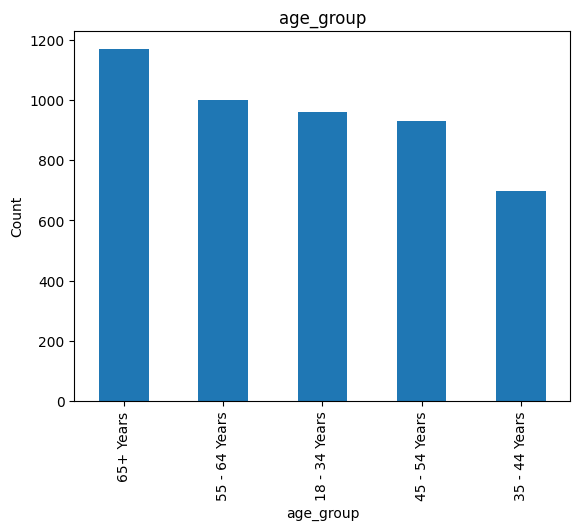

Column: education
education
College Graduate    1879
Some College        1209
12 Years             992
< 12 Years           406
NaN                  270
Name: count, dtype: int64


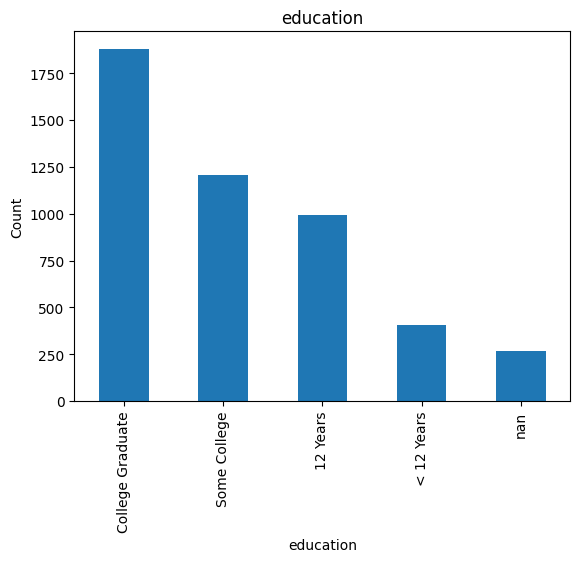

Column: race
race
White                3766
Black                 362
Other or Multiple     317
Hispanic              311
Name: count, dtype: int64


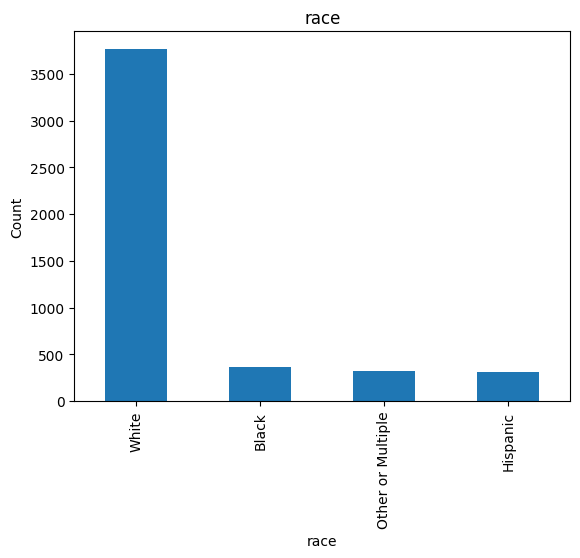

Column: sex
sex
Female    2783
Male      1973
Name: count, dtype: int64


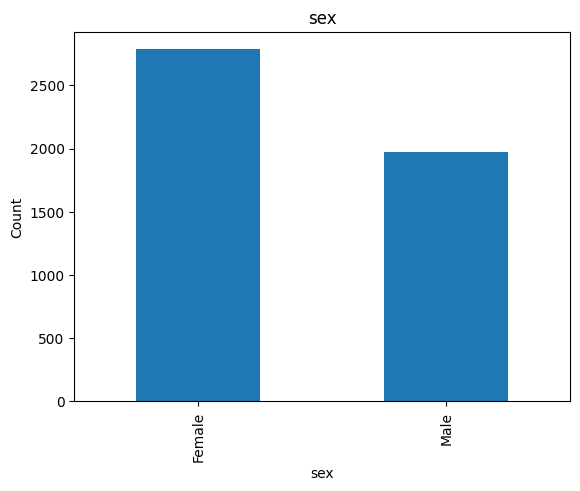

Column: income_poverty
income_poverty
<= $75,000, Above Poverty    2258
> $75,000                    1250
NaN                           790
Below Poverty                 458
Name: count, dtype: int64


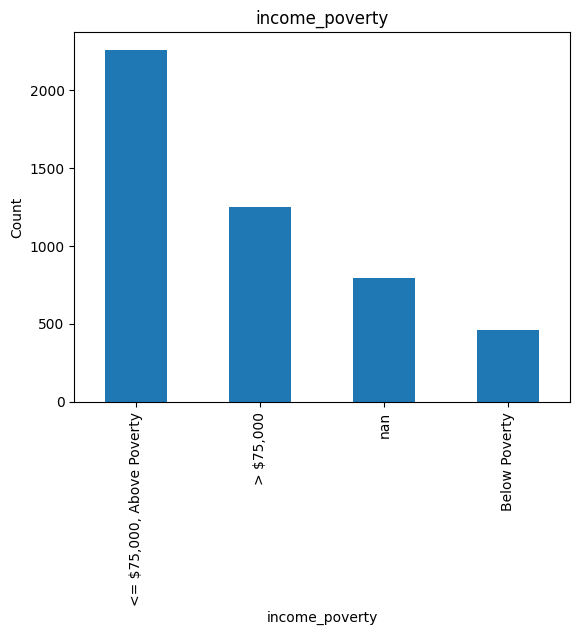

Column: marital_status
marital_status
Married        2403
Not Married    2088
NaN             265
Name: count, dtype: int64


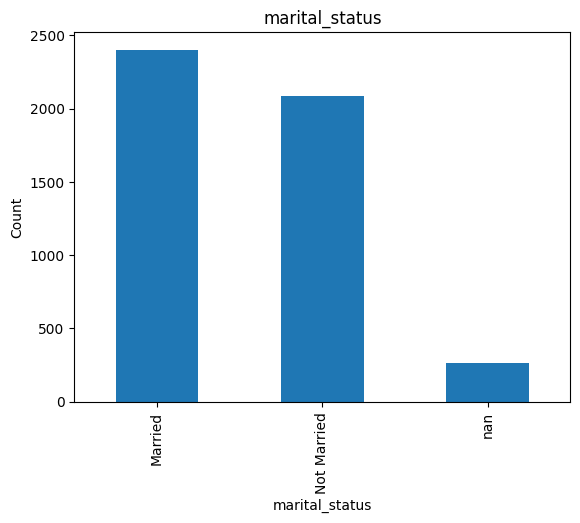

In [16]:
for col in cat_cols[:6]:
    print('Column:', col)
    print(data[col].value_counts(dropna=False).head(10))

    data[col].value_counts(dropna=False).head(10).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.show()

##Relationship with target


In [17]:
for col in cat_cols[:6]:
    print('', col)
    print(data.groupby(col)[target].mean().sort_values(ascending=False).head(10))

 age_group
age_group
65+ Years        0.725406
55 - 64 Years    0.608609
45 - 54 Years    0.497315
35 - 44 Years    0.426112
18 - 34 Years    0.348958
Name: seasonal_vaccine, dtype: float64
 education
education
College Graduate    0.597658
Some College        0.518610
12 Years            0.511089
< 12 Years          0.448276
Name: seasonal_vaccine, dtype: float64
 race
race
White                0.569304
Other or Multiple    0.485804
Black                0.381215
Hispanic             0.369775
Name: seasonal_vaccine, dtype: float64
 sex
sex
Female    0.571685
Male      0.486569
Name: seasonal_vaccine, dtype: float64
 income_poverty
income_poverty
> $75,000                    0.595200
<= $75,000, Above Poverty    0.532329
Below Poverty                0.436681
Name: seasonal_vaccine, dtype: float64
 marital_status
marital_status
Married        0.575947
Not Married    0.506705
Name: seasonal_vaccine, dtype: float64


In [19]:
for col in numeric_cols[:6]:
    print('', col)
    print(data.groupby(target)[col].mean())

 flu_concern
seasonal_vaccine
0    1.481128
1    1.783104
Name: flu_concern, dtype: float64
 flu_knowledge
seasonal_vaccine
0    1.189325
1    1.382527
Name: flu_knowledge, dtype: float64
 behavioral_antiviral_meds
seasonal_vaccine
0    0.057273
1    0.047994
Name: behavioral_antiviral_meds, dtype: float64
 behavioral_avoidance
seasonal_vaccine
0    0.689010
1    0.773212
Name: behavioral_avoidance, dtype: float64
 behavioral_face_mask
seasonal_vaccine
0    0.062642
1    0.083529
Name: behavioral_face_mask, dtype: float64
 behavioral_wash_hands
seasonal_vaccine
0    0.788732
1    0.877896
Name: behavioral_wash_hands, dtype: float64


# Pre-processing

##Separating features and target


In [21]:
data = data.dropna(subset=[target])

X = data.drop(columns=[target, id_col], errors='ignore')
y = data[target].astype(int)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (4756, 29)
y shape: (4756,)


##Handling missing values

In [22]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('Missing')
    else:
        X[col] = X[col].fillna(X[col].median())

##Encoding categorical columns


In [23]:
X = pd.get_dummies(X)

print('Final feature shape:', X.shape)
X.head()

Final feature shape: (4756, 74)


,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,...,employment_sector_media,employment_sector_mining,employment_sector_real_estate,employment_sector_retail,employment_sector_science,employment_sector_services,employment_sector_technology,employment_sector_transportation,employment_sector_utilities,employment_sector_wholesale
0,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False


## Train validation split

In [24]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)

print('Training rows:', X_train.shape[0])
print('Validation rows:', X_valid.shape[0])

Training rows: 3804
Validation rows: 952


# Modelling

##Models comparision

In [31]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    score = f1_score(y_valid, preds)
    results.append([name, score])
    print(name, 'F1 score:', round(score, 4))

results = pd.DataFrame(results, columns=['Model', 'F1 Score'])
results.sort_values('F1 Score', ascending=False)

Logistic Regression F1 score: 0.7949
Random Forest F1 score: 0.7818
Gradient Boosting F1 score: 0.8055


,Model,F1 Score
2,Gradient Boosting,0.805474
0,Logistic Regression,0.794897
1,Random Forest,0.781765


# Performance Analysis and Tuning

##hyperparameter tuning


In [27]:
best_score = 0
best_trees = 0
best_depth = 0
best_model = None

for trees in [100, 200, 300]:
    for depth in [5, 10, 15, None]:
        model = RandomForestClassifier(
            n_estimators=trees,
            max_depth=depth,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_valid)
        score = f1_score(y_valid, preds)

        print('Trees:', trees, '| Depth:', depth, '| F1:', round(score, 4))

        if score > best_score:
            best_score = score
            best_trees = trees
            best_depth = depth
            best_model = model

print('Best trees:', best_trees)
print('Best depth:', best_depth)
print('Best F1:', round(best_score, 4))

Trees: 100 | Depth: 5 | F1: 0.7767
Trees: 100 | Depth: 10 | F1: 0.783
Trees: 100 | Depth: 15 | F1: 0.7847
Trees: 100 | Depth: None | F1: 0.7818
Trees: 200 | Depth: 5 | F1: 0.7725
Trees: 200 | Depth: 10 | F1: 0.7809
Trees: 200 | Depth: 15 | F1: 0.7829
Trees: 200 | Depth: None | F1: 0.7776
Trees: 300 | Depth: 5 | F1: 0.768
Trees: 300 | Depth: 10 | F1: 0.7796
Trees: 300 | Depth: 15 | F1: 0.7797
Trees: 300 | Depth: None | F1: 0.7856
Best trees: 300
Best depth: None
Best F1: 0.7856


##Threshold tuning for F1

The default threshold is 0.5.  
Because the metric is F1 score, changing the threshold can improve the result.

In [28]:
probabilities = best_model.predict_proba(X_valid)[:, 1]

best_threshold = 0.5
best_threshold_f1 = 0

for threshold in np.arange(0.1, 0.91, 0.01):
    preds = (probabilities >= threshold).astype(int)
    score = f1_score(y_valid, preds)

    if score > best_threshold_f1:
        best_threshold_f1 = score
        best_threshold = threshold

print('Best threshold:', round(best_threshold, 2))
print('Best F1 after threshold tuning:', round(best_threshold_f1, 4))

Best threshold: 0.42
Best F1 after threshold tuning: 0.7982


##Final validation results

In [29]:
final_valid_preds = (probabilities >= best_threshold).astype(int)

print('Classification Report:')
print(classification_report(y_valid, final_valid_preds))

print('Confusion Matrix:')
print(confusion_matrix(y_valid, final_valid_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.64      0.71       441
           1       0.74      0.87      0.80       511

    accuracy                           0.76       952
   macro avg       0.77      0.76      0.76       952
weighted avg       0.77      0.76      0.76       952

Confusion Matrix:
[[282 159]
 [ 66 445]]


##Training final model on all training data

After selecting the best setting, we train again using all available labelled data.

In [30]:
final_model = RandomForestClassifier(
    n_estimators=best_trees,
    max_depth=best_depth,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

final_model.fit(X, y)

joblib.dump(final_model, 'final_hackathon_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')
joblib.dump(best_threshold, 'best_threshold.pkl')

print('Final model saved')

Final model saved


#Model Testing


In [33]:
test = pd.read_csv('/content/dataset_A_testing.csv')
test_ids = test[id_col]
X_test = test.drop(columns=[id_col], errors='ignore')

for col in X_test.columns:
    if X_test[col].dtype == 'object':
        X_test[col] = X_test[col].fillna('Missing')
    else:
        X_test[col] = X_test[col].fillna(X_test[col].median())

X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

test_probabilities = final_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= best_threshold).astype(int)

submission = pd.DataFrame({
    id_col: test_ids,
    target: test_predictions
})

submission.to_csv('submission.csv', index=False)
submission.head()

,respondent_id,seasonal_vaccine
0,4757,1
1,4758,1
2,4759,1
3,4760,1
4,4761,0
